# L5a Advanced: Sampling Error and Shrinkage in Covariance Estimation

The L5a lecture ended its covariance section with a caveat: a matrix with $M(M+1)/2$ distinct entries estimated from $N$ observations is noisy when $M$ is not small relative to $N$, and estimates must be checked before they are used. This notebook makes the caveat concrete for our dataset (424 firms, about 2800 trading days). We look at the eigenvalues of the sample correlation matrix and compare them with what pure noise would produce, measure how the estimation error scales with the sample size, and then repair the estimate with shrinkage and test whether the repair helps the one thing L5b will build from it: a minimum-variance portfolio, evaluated out of sample.

> __Learning Objectives:__
>
> By the end of this example, you should be able to:
> - **Diagnose noise in a sample covariance with its spectrum:** Compare the eigenvalues of the sample correlation matrix with the Marchenko-Pastur law for a pure-noise matrix of the same shape, and distinguish spectral outliers from directions that the eigenvalues alone do not separate from the null.
> - **Measure how estimation error scales:** Simulate growth rates from a known covariance, re-estimate it from samples of increasing length, and see the error shrink like the inverse square root of the sample size while the smallest eigenvalues stay unreliable.
> - **Shrink and test out of sample:** Apply linear shrinkage toward three structured targets over a range of intensities, build minimum-variance portfolios from the raw and the shrunk estimates on a training window, and compare their realized variances on a later test window.

Let's get started!

___

## Setup, Data, and Prerequisites

We use the course training dataset and the growth-rate covariance $\hat{\mathbf{\Sigma}}_{g}$ of the L5a covariance example. The local `Include.jl` file activates the course project and loads the required packages.

> The [`include(...)` command](https://docs.julialang.org/en/v1/base/base/#include) evaluates `Include.jl` in the notebook's global scope. Here, [`Include.jl`](Include.jl) activates the nearest course project and loads the external packages used below; the notebook defines its own analysis helpers in later cells. For additional information on the functions and types used here, see the [Julia programming language documentation](https://docs.julialang.org/en/v1/).

Let's set up our code environment:

In [1]:
include(joinpath(@__DIR__, "Include.jl")); # Load the local setup file.

  Activating 

project at `~/Desktop/julia_work/CHEME-5660-CourseRepository-Fall-2026`


The [`Include.jl`](Include.jl) file activates the course project and loads [the `VLQuantitativeFinancePackage.jl` package](https://varnerlab.org/CHEME-5660-CourseRepository-Fall-2026/dev/) for the dataset and growth-rate matrix, [the `DataFrames.jl` package](https://dataframes.juliadata.org/stable/) for tabular results, [the `Distributions.jl` package](https://juliastats.org/Distributions.jl/stable/) for the multivariate normal, the `LinearAlgebra`, `Statistics`, and `Random` standard libraries, [the `Plots.jl` package](https://docs.juliaplots.org/stable/) for figures, and [the `PrettyTables.jl` package](https://ronisbr.github.io/PrettyTables.jl/stable/) for tables. This notebook defines its own functions, so no local source files are loaded. Let's set the plotting defaults:

In [2]:
default(
    fontfamily = "Helvetica",
    framestyle = :box,
    background_color = :gray97,
    background_color_outside = :white,
    legend_background_color = nothing,
    linewidth = 2,
);

### Data
We use the daily open-high-low-close data for the firms in the [S&P 500](https://en.wikipedia.org/wiki/S%26P_500) from January 3, 2014 until December 31, 2024 (the training data of the L4b and L5a examples). Let's load it with [the `MyTrainingMarketDataSet()` function](https://varnerlab.org/CHEME-5660-CourseRepository-Fall-2026/dev/data/#VLQuantitativeFinancePackage.MyTrainingMarketDataSet), keep the firms with the maximum number of trading days, sort the tickers, and build the growth-rate data matrix $\mathbf{G}\in\mathbb{R}^{N\times M}$ with [the `log_growth_matrix(...)` function](https://varnerlab.org/CHEME-5660-CourseRepository-Fall-2026/dev/equity/#VLQuantitativeFinancePackage.log_growth_matrix). We store the matrix in the `G::Array{Float64,2}` variable and the tickers in `list_of_tickers::Array{String,1}`:

In [3]:
G, list_of_tickers = let
    original_dataset = MyTrainingMarketDataSet() |> x-> x["dataset"];
    maximum_number_trading_days = original_dataset["AAPL"] |> nrow;
    dataset = Dict(k => v for (k, v) ∈ original_dataset if nrow(v) == maximum_number_trading_days);
    list_of_tickers = keys(dataset) |> collect |> sort;
    G = log_growth_matrix(dataset, list_of_tickers); # growth rates, N × M
    (G, list_of_tickers)
end;
N, M = size(G)
println("N = $(N) trading days of growth rates for M = $(M) firms; aspect ratio q = M/N = $(round(M/N, digits=3))")

N = 2766 trading days of growth rates for M = 424 firms; aspect ratio q = M/N = 0.153


___

## 1. The spectrum of the sample correlation matrix

Let $\hat{\mathbf{\Sigma}}_{g}$ be the sample growth-rate covariance and $\hat{\mathbf{R}}$ the corresponding correlation matrix (divide each entry by the two standard deviations). Both are symmetric and positive semidefinite, so their eigenvalues are real and non-negative, and the eigenvalues of $\hat{\mathbf{R}}$ sum to $M$. If the $M$ firms were __independent__ with unit variance, the true correlation matrix would be the identity, but the sample correlation matrix estimated from $N$ observations would not be: its eigenvalues would scatter around one, and the Marchenko-Pastur law says how. For $N,M\to\infty$ with aspect ratio $q=M/N$ fixed, the eigenvalues of a pure-noise sample correlation matrix have density:
$$
f(\lambda) = \frac{\sqrt{(\lambda_{+}-\lambda)(\lambda-\lambda_{-})}}{2\pi q\,\lambda},\qquad \lambda_{\pm}=\left(1\pm\sqrt{q}\right)^{2},
$$
on the interval $[\lambda_{-},\lambda_{+}]$ and zero outside. With $q\approx0.15$ that interval is roughly $[0.37,1.93]$: pure noise produces eigenvalues anywhere from about a third to about twice the true value of one. An eigenvalue inside this bulk is not separated from the pure-noise null by its size alone; an eigenvalue far above the edge is evidence of structure that this null does not produce. Let's compute the sample correlation matrix and its eigenvalues:

In [4]:
Σ̂_g = cov(G, dims=1); # growth-rate covariance, 1/yr²
σ_g = sqrt.(diag(Σ̂_g));
R̂ = Σ̂_g ./ (σ_g*σ_g'); # sample correlation matrix
λ = eigvals(Symmetric(R̂)) |> reverse; # eigenvalues, largest first
q = M/N; λ_minus = (1 - sqrt(q))^2; λ_plus = (1 + sqrt(q))^2;
println("Marchenko-Pastur bulk for q = $(round(q, digits=3)): [$(round(λ_minus, digits=3)), $(round(λ_plus, digits=3))]")
println("Largest eigenvalues: $(round.(λ[1:6], digits=2))")
println("Number of eigenvalues above the bulk edge λ₊: $(count(λ .> λ_plus)) of $(M); sum of all eigenvalues: $(round(sum(λ), digits=1))")

Marchenko-Pastur bulk for q = 0.153: [0.37, 1.936]


Largest eigenvalues: [143.74, 22.64, 16.96, 9.03, 6.6, 5.79]
Number of eigenvalues above the bulk edge λ₊: 18 of 424; sum of all eigenvalues: 424.0


The largest eigenvalue is far above one and is consistent with a broad market component; confirming that label requires inspecting its eigenvector loadings. Several other eigenvalues also sit above the bulk edge and may reflect sectors or other shared drivers. Because the eigenvalues must sum to $M$, the variance captured by those few large eigenvalues is taken away from all the others, so the noise bulk of a real correlation matrix sits __below__ where the pure-noise law puts it. The standard correction of [Laloux and co-workers (1999)](https://doi.org/10.1103/PhysRevLett.83.1467) is to compare the small eigenvalues with a Marchenko-Pastur law whose variance parameter is the mean residual eigenvalue after removing the structured eigenvalues, $\sigma^{2}_{\text{bulk}}=(M-\sum_{\text{structured}}\lambda_{i})/(M-K)$, where $K$ is the number of removed outliers. This rescales the bulk to $[\sigma^{2}_{\text{bulk}}\lambda_{-},\sigma^{2}_{\text{bulk}}\lambda_{+}]$. We make an explicit one-pass heuristic choice, treating the eigenvalues above the naive edge as the structured set. Iterating this threshold would change the selected set and eventually converge to a different split; the one-pass result is used only to show how residual-variance rescaling changes the comparison, not to estimate a uniquely defined number of factors. Let's compute the rescaling, count how many eigenvalues fall below, inside, and above the rescaled bulk, and plot the histogram of the eigenvalues that lie inside or near the bulk against both the naive and the rescaled densities:

Above the pure-noise edge λ₊ = 1.936: 18 eigenvalues, holding 56.8% of the total variance; residual-bulk mean σ²_bulk = 0.451


Relative to the rescaled bulk [0.167, 0.873]: 90 eigenvalues below, 266 inside, and 68 above


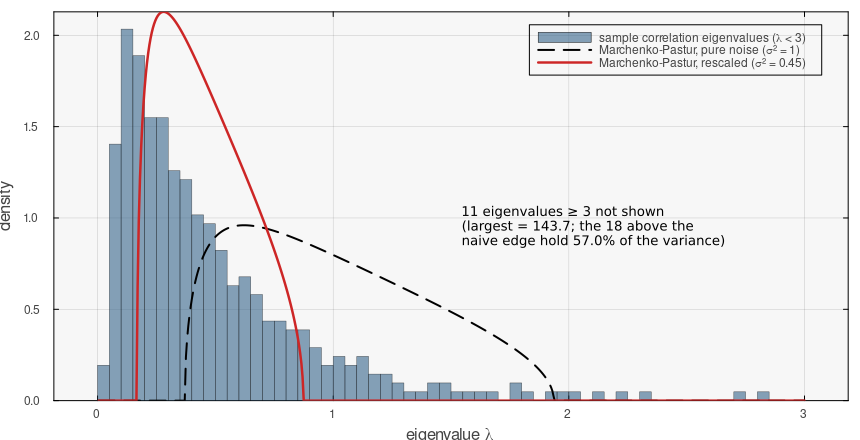

In [5]:
mp(λ, s²) = (s²*λ_minus < λ < s²*λ_plus) ? sqrt((s²*λ_plus - λ)*(λ - s²*λ_minus))/(2π*q*s²*λ) : 0.0

K_naive = count(λ .> λ_plus); # number of eigenvalues above the pure-noise bulk edge
structured_share = sum(λ[1:K_naive])/sum(λ); # fraction of variance in those eigenvalues
s²_bulk = (M - sum(λ[1:K_naive]))/(M - K_naive); # mean eigenvalue of the residual bulk
rescaled_lower = s²_bulk*λ_minus; rescaled_upper = s²_bulk*λ_plus;
K_below_rescaled = count(λ .< rescaled_lower);
K_above_rescaled = count(λ .> rescaled_upper);
K_inside_rescaled = M - K_below_rescaled - K_above_rescaled;
println("Above the pure-noise edge λ₊ = $(round(λ_plus, digits=3)): $(K_naive) eigenvalues, holding $(round(100*structured_share, digits=1))% of the total variance; residual-bulk mean σ²_bulk = $(round(s²_bulk, digits=3))")
println("Relative to the rescaled bulk [$(round(rescaled_lower, digits=3)), $(round(rescaled_upper, digits=3))]: $(K_below_rescaled) eigenvalues below, $(K_inside_rescaled) inside, and $(K_above_rescaled) above")

let
    λ_bulk = λ[λ .< 3.0]; # eigenvalues near or inside the bulk (the market and sector eigenvalues are far above)
    p = histogram(λ_bulk; bins = 0:0.05:3.0, normalize = :pdf, color = :steelblue4, alpha = 0.6, lw = 0.5,
        label = "sample correlation eigenvalues (λ < 3)", xlabel = "eigenvalue λ", ylabel = "density", size = (860, 440))
    xs = range(0.005, 3.0, length = 600)
    plot!(p, xs, mp.(xs, 1.0); color = :black, lw = 2, linestyle = :dash, label = "Marchenko-Pastur, pure noise (σ² = 1)")
    plot!(p, xs, mp.(xs, s²_bulk); color = :firebrick3, lw = 2.5, label = "Marchenko-Pastur, rescaled (σ² = $(round(s²_bulk, digits=2)))")
    annotate!(p, 1.55, 0.45*maximum(mp.(xs, s²_bulk)), text("$(count(λ .>= 3.0)) eigenvalues ≥ 3 not shown\n(largest = $(round(λ[1], digits=1)); the $(K_naive) above the\nnaive edge hold $(round(100*structured_share, digits=0))% of the variance)", 9, :left))
    p
end

Once the eighteen eigenvalues above the naive edge are accounted for, the rescaled noise law is closer to the empirical bulk than the naive unit-variance law: well over half of the total variance lives in those few directions, and what remains is spread thin over the other four hundred. The match is not exact: the empirical spectrum is broader than the rescaled law, with eigenvalues beyond both its lower and upper edges. Real growth rates are not Gaussian noise plus a few factors; heavy tails, changing volatilities, and residual sector structure can all widen the spectrum. The Marchenko-Pastur comparison is therefore a heuristic null, not a test, and the exact number of structured directions is not sharply defined. A majority of the eigenvalues lie inside the rescaled bulk, but that only means the spectrum alone does not distinguish those directions from the idealized null; it does not prove that they are pure noise. The fine detail of these directions remains unresolved by this comparison, and a calculation that leans on it, such as inverting the covariance matrix, can amplify estimation error. Let's quantify that error.


___

## 2. How the estimation error scales with the sample size

To measure estimation error we need a truth. Let's pretend the sample covariance $\hat{\mathbf{\Sigma}}_{g}$ __is__ the truth $\mathbf{\Sigma}$, simulate $N^{\prime}$ days of multivariate normal growth rates with that covariance, re-estimate the covariance from the simulated sample, and compare with the truth. Two error measures: the relative Frobenius error $\lVert\hat{\mathbf{\Sigma}}^{\prime}-\mathbf{\Sigma}\rVert_{F}/\lVert\mathbf{\Sigma}\rVert_{F}$ (the size of the whole error matrix), and the smallest eigenvalue of the estimate against the smallest eigenvalue of the truth (the direction where the inverse blows up). We repeat for $N^{\prime}$ from one year of days up to the full sample, averaging over twenty replicates and reporting the spread across them, and store the results in the `error_table::DataFrame` variable:

In [6]:
error_table = let
    Σ = Symmetric(Σ̂_g); # reference covariance for the simulation study
    d = MvNormal(zeros(M), Σ);
    rng = MersenneTwister(5660);
    λ_true_min = minimum(eigvals(Σ));
    R = 20; # replicates per sample length
    df = DataFrame(N_prime = Int[], rel_frobenius_error = Float64[], error_sd = Float64[], min_eig_estimate = Float64[], min_eig_true = Float64[])
    for N′ ∈ (250, 500, 1000, 2000, N)
        errs = zeros(R); mins = zeros(R)
        for r ∈ 1:R
            X = rand(rng, d, N′)'; # N′ × M simulated growth rates
            Σ′ = cov(X, dims=1);
            errs[r] = norm(Σ′ - Σ)/norm(Σ); mins[r] = minimum(eigvals(Symmetric(Σ′)))
        end
        push!(df, (N′, mean(errs), std(errs), mean(mins), λ_true_min))
    end
    df
end
pretty_table(error_table; formatters = [fmt__printf("%.4f", [2,3,4,5])])

┌─────────┬─────────────────────┬──────────┬──────────────────┬──────────────┐
│ N_prime │ rel_frobenius_error │ error_sd │ min_eig_estimate │ min_eig_true │
│   Int64 │             Float64 │  Float64 │          Float64 │      Float64 │
├─────────┼─────────────────────┼──────────┼──────────────────┼──────────────┤
│     250 │              0.2077 │   0.0337 │          -0.0000 │       0.0506 │
│     500 │              0.1379 │   0.0145 │           0.0074 │       0.0506 │
│    1000 │              0.0976 │   0.0095 │           0.0292 │       0.0506 │
│    2000 │              0.0702 │   0.0050 │           0.0394 │       0.0506 │
│    2766 │              0.0568 │   0.0045 │           0.0426 │       0.0506 │
└─────────┴─────────────────────┴──────────┴──────────────────┴──────────────┘


Let's plot the relative error against $N^{\prime}$ on log axes with a $1/\sqrt{N^{\prime}}$ reference:

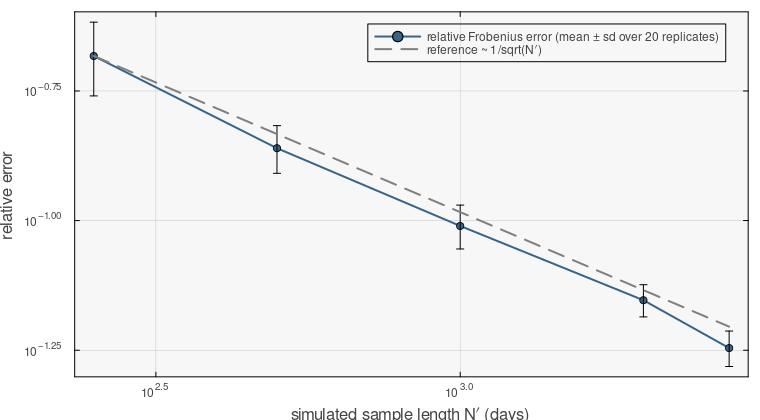

In [7]:
let
    plot(error_table.N_prime, error_table.rel_frobenius_error; xscale = :log10, yscale = :log10, marker = :circle, color = :steelblue4,
        yerror = error_table.error_sd, label = "relative Frobenius error (mean ± sd over 20 replicates)", xlabel = "simulated sample length N′ (days)", ylabel = "relative error", size = (760, 420), legend = :topright)
    ref = error_table.rel_frobenius_error[1] .* sqrt.(error_table.N_prime[1] ./ error_table.N_prime)
    plot!(error_table.N_prime, ref; color = :gray50, linestyle = :dash, label = "reference ~ 1/sqrt(N′)")
end

The overall error falls like $1/\sqrt{N^{\prime}}$, as sampling error should. But look at the smallest eigenvalue: with one year of data it is essentially zero (the estimate is singular in some direction), and even with the full sample it is well short of the truth. Those are exactly the directions a minimum-variance optimizer likes, because they look like free risk reduction. Left uncorrected, the optimizer will bet on noise.


___

## 3. Shrinkage, and whether it helps out of sample

__Shrinkage__ pulls the noisy sample covariance toward a simpler, better-conditioned __target__ $\mathbf{F}$ as follows:
$$
\hat{\mathbf{\Sigma}}_{\delta} = (1-\delta)\,\hat{\mathbf{\Sigma}} + \delta\,\mathbf{F},\qquad 0\leq\delta\leq1,
$$
where $\delta$ is the shrinkage intensity. Three common targets, in order of how much structure they keep: the scaled identity $\bar{\lambda}\mathbf{I}$ with $\bar{\lambda}=\operatorname{tr}(\hat{\mathbf{\Sigma}})/M$ (all variances equal, no correlation); the diagonal $\operatorname{diag}(\hat{\mathbf{\Sigma}})$ (each firm keeps its own variance, correlations shrink toward zero); and the constant-correlation target (each firm keeps its variance, every pair gets the average correlation $\bar{\rho}$), studied for stock returns by [Ledoit and Wolf](https://doi.org/10.3905/jpm.2004.110). Every target lifts the smallest eigenvalues, so the inverse stops blowing up; the targets differ in what they assume about the structure. Ledoit and Wolf give a data-driven formula for the intensity for each target; here we do something more transparent and sweep $\delta$ and let a test window judge.

To test whether shrinkage helps where it matters, we split the data: the first eight years are the __training window__ (estimate covariances), the last three years are the __test window__ (evaluate). From each estimate we build the unconstrained minimum-variance portfolio, whose weights have the following closed form (L5b derives the constrained version):
$$
\mathbf{w}_{\min}=\frac{\hat{\mathbf{\Sigma}}_{\delta}^{-1}\mathbf{1}}{\mathbf{1}^{\top}\hat{\mathbf{\Sigma}}_{\delta}^{-1}\mathbf{1}},
$$
and then compute the __realized__ standard deviation of that portfolio's growth rate on the test window, which the estimate never saw. We compare the three targets over a grid of intensities, with the equal-weight portfolio $1/M$ (which needs no covariance at all) as the baseline. Let's set up the split and the targets:

In [8]:
N_train = 8*252; # first eight years of the training data
G_train = G[1:N_train, :]; G_test = G[(N_train+1):end, :];
S_train = cov(G_train, dims=1);
targets = let
    σ = sqrt.(diag(S_train)); R = S_train ./ (σ*σ'); ρ̄ = (sum(R) - M)/(M*(M - 1)); # average off-diagonal correlation
    F_cc = ρ̄ .* (σ*σ'); F_cc[diagind(F_cc)] .= σ.^2;
    Dict("scaled identity" => Matrix((tr(S_train)/M)*I(M)), "diagonal" => Matrix(Diagonal(diag(S_train))), "constant correlation" => F_cc)
end;
minvar(Σ) = (w = Symmetric(Σ) \ ones(M); w ./ sum(w));                 # unconstrained minimum-variance weights
realized_std(w, X) = std(X*w);                                        # growth-rate standard deviation on a window (units: 1/year)
println("Training window: $(N_train) days; test window: $(size(G_test,1)) days; average off-diagonal correlation on training: $(round((sum(S_train ./ (sqrt.(diag(S_train))*sqrt.(diag(S_train))')) - M)/(M*(M-1)), digits=3))")

Training window: 2016 days; test window: 750 days; average off-diagonal correlation on training: 0.336


Now the sweep. For each target and each $\delta$ we build the portfolio on the training window and record its realized standard deviation on both windows, plus the sum of the absolute weights (a large value means the optimizer took big long and short positions, a symptom of betting on noise). We store the results in the `shrinkage_df::DataFrame` variable:

In [9]:
shrinkage_df = let
    δ_grid = [0.0, 0.01, 0.02, 0.05, 0.1, 0.2, 0.3, 0.5, 0.75, 1.0]
    df = DataFrame(target = String[], δ = Float64[], train_std = Float64[], test_std = Float64[], sum_abs_weights = Float64[])
    for name ∈ ("scaled identity", "diagonal", "constant correlation"), δ ∈ δ_grid
        w = minvar((1 - δ)*S_train + δ*targets[name])
        push!(df, (name, δ, realized_std(w, G_train), realized_std(w, G_test), sum(abs.(w))))
    end
    w_eq = ones(M)/M
    push!(df, ("equal weights 1/M", NaN, realized_std(w_eq, G_train), realized_std(w_eq, G_test), 1.0))
    df
end;
let
    println("Best test-window standard deviation by target (δ chosen with hindsight):")
    for name ∈ ("scaled identity", "diagonal", "constant correlation")
        sdf = filter(r -> r.target == name, shrinkage_df); k = argmin(sdf.test_std)
        println("  $(rpad(name, 22)) δ = $(sdf.δ[k])  train std = $(round(sdf.train_std[k], digits=3))  test std = $(round(sdf.test_std[k], digits=3))  sum|w| = $(round(sdf.sum_abs_weights[k], digits=2))")
    end
    println("No shrinkage (δ = 0): test std = $(round(shrinkage_df[1,:test_std], digits=3)), sum|w| = $(round(shrinkage_df[1,:sum_abs_weights], digits=2)); equal weights: test std = $(round(shrinkage_df[end,:test_std], digits=3))")
end

Best test-window standard deviation by target (δ chosen with hindsight):


  scaled identity        δ = 0.0  train std = 0.777  test std = 1.285  sum|w| = 6.41


  diagonal               δ = 0.1  train std = 0.837  test std = 1.229  sum|w| = 4.53
  constant correlation   δ = 0.2  train std = 0.87  test std = 1.186  sum|w| = 4.64
No shrinkage (δ = 0): test std = 1.285, sum|w| = 6.41; equal weights: test std = 2.378


Let's plot the training and test standard deviations against $\delta$ for the three targets, over the useful range $\delta\leq0.5$ (at $\delta=1$ all three targets give a test standard deviation between 2.1 and 2.4, close to equal weights, because the covariance structure has effectively been discarded):

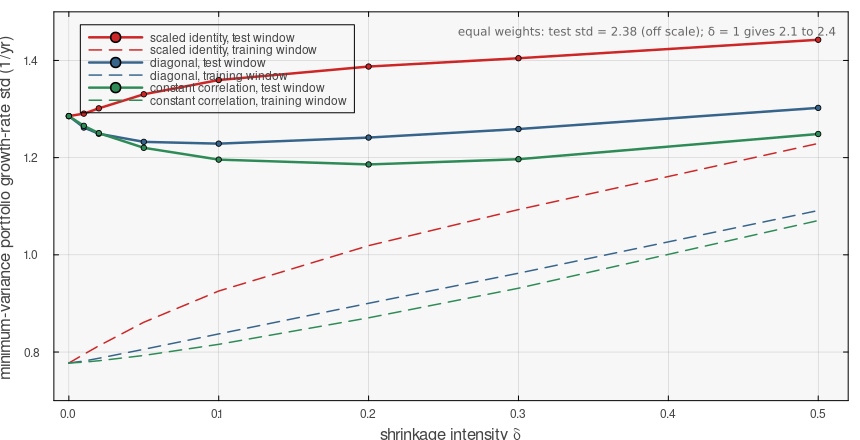

In [10]:
let
    p = plot(xlabel = "shrinkage intensity δ", ylabel = "minimum-variance portfolio growth-rate std (1/yr)", size = (860, 440), legend = :topleft, xlims = (-0.01, 0.52), ylims = (0.7, 1.5))
    colors = Dict("scaled identity" => :firebrick3, "diagonal" => :steelblue4, "constant correlation" => :seagreen4)
    for name ∈ ("scaled identity", "diagonal", "constant correlation")
        sdf = filter(r -> r.target == name && r.δ <= 0.5, shrinkage_df)
        plot!(p, sdf.δ, sdf.test_std; color = colors[name], lw = 2.5, marker = :circle, ms = 3, label = "$(name), test window")
        plot!(p, sdf.δ, sdf.train_std; color = colors[name], lw = 1.5, linestyle = :dash, label = "$(name), training window")
    end
    annotate!(p, 0.26, 1.46, text("equal weights: test std = $(round(shrinkage_df[end, :test_std], digits=2)) (off scale); δ = 1 gives 2.1 to 2.4", 8, :left, :gray40))
    p
end

Read the figure in two halves. The dashed training curves all rise from $\delta=0$: in sample, the raw sample covariance always wins, because the optimizer has found the directions where the noise made risk look small. The solid test curves say something else. For the diagonal and constant-correlation targets, moderate shrinkage ($\delta$ around $0.1$ to $0.2$) __lowers__ the realized out-of-sample risk by several percent while cutting the size of the long and short positions; shrinking all the way to a target ($\delta=1$) imposes that target completely and is worse here than no shrinkage. The scaled-identity target is different: it hurts at every $\delta$, because equity variances differ by an order of magnitude and forcing them toward a common value distorts the estimate more than it stabilizes it. Which target you shrink toward matters as much as how far. And every moderately shrunk portfolio (and the raw one) beats equal weights by a wide margin on the test window; at $\delta=1$, each target discards all sample deviations from its assumed structure, and the resulting test risks move toward the equal-weight scale. In this split, estimating covariance helps, while moderate structured shrinkage improves the raw estimate further.

The exact numbers depend on the split and the period, and $\delta$ was chosen here with the test window in view, so this is an illustration, not a validated recipe (a real study would choose $\delta$ on the training data, by cross-validation or the Ledoit-Wolf formula for the chosen target, and use rolling windows). The direction of the effect is what the shrinkage literature reports across many datasets. Estimation error in a large covariance is not a rounding issue: it changes decisions, and shrinkage toward a sensible target (or the factor models of L6) is how it is managed.


___

## Summary

This notebook made the lecture's caveat quantitative for our own dataset: many directions in a sample covariance of hundreds of firms are not separated from a pure-noise spectral null, the error shrinks slowly with the sample size, and shrinkage toward a structured target is a practical repair whose value shows up out of sample.

> __Key Takeaways:__
>
> - **The spectrum tells you what is signal:** Against the Marchenko-Pastur law for pure noise, only a minority of sample-correlation eigenvalues stand above the null edge; eigenvalue size alone does not distinguish the bulk from noise.
> - **Error scales like one over the square root of the sample, and the small eigenvalues are worst:** Simulating from a known covariance shows the overall error falling slowly while the smallest eigenvalues remain unreliable, which is exactly where an optimizer looks.
> - **Shrinkage can improve test-window stability if the target is sensible:** In this split, pulling the estimate part way toward the diagonal or the constant-correlation target lifts the small eigenvalues and lowers realized test-window risk, while a scaled-identity target hurts because it distorts unequal variances.

L5b builds the constrained minimum-variance portfolio from the covariance; everything here says which covariance to hand it.


___

## Disclaimer and Risks

This notebook is for instruction only. Covariance estimates and portfolio weights depend on the sample window and the estimator; the split-sample comparison here is one split, not a backtest. This material is not investment or trading advice.
